In [53]:
import random
from dataclasses import dataclass, field
from PIL import Image, ImageDraw

# --- Dice sample structure ---

MIN_DIE_SIZE = 60
MAX_DIE_SIZE = 100

@dataclass
class Die:
    value: int
    x: int
    y: int
    size: int = 80
    angle: float = 0.0


@dataclass
class DiceScene:
    dice: list[Die] = field(default_factory=list)

    def __post_init__(self):
        self._validate()

    def _validate(self):
        if not (1 <= len(self.dice) <= 3):
            raise ValueError("A scene must contain between 1 and 3 dice.")

        for die in self.dice:
            if not (1 <= die.value <= 6):
                raise ValueError(f"Die value must be between 1 and 6, got {die.value}.")
            if not (MIN_DIE_SIZE <= die.size <= MAX_DIE_SIZE):
                raise ValueError(
                    f"Die size must be between {MIN_DIE_SIZE} and {MAX_DIE_SIZE}, got {die.size}."
                )

        positions = [(die.x, die.y) for die in self.dice]
        if len(positions) != len(set(positions)):
            raise ValueError("Two dice cannot have exactly the same top-left position.")

    def values(self) -> list[int]:
        return [die.value for die in self.dice]

    def count(self) -> int:
        return len(self.dice)

    def __str__(self) -> str:
        return " | ".join(
            [f"Die(value={d.value}, x={d.x}, y={d.y}, size={d.size})" for d in self.dice]
        )

In [54]:
#test
scene = DiceScene([
    Die(value=3, x=30, y=40),
    Die(value=5, x=150, y=50)
])

print(scene)
print(scene.count())
print(scene.values())

Die(value=3, x=30, y=40, size=80) | Die(value=5, x=150, y=50, size=80)
2
[3, 5]


In [55]:
# --- Random scene generator ---

CANVAS_SIZE = 320
MARGIN = 20
MIN_DIE_SIZE = 60
MAX_DIE_SIZE = 100

def _overlap(d1: Die, d2: Die, padding: int = 10) -> bool:
    return not (
        d1.x + d1.size + padding <= d2.x or
        d2.x + d2.size + padding <= d1.x or
        d1.y + d1.size + padding <= d2.y or
        d2.y + d2.size + padding <= d1.y
    )


def _is_valid_placement(new_die: Die, placed_dice: list[Die], padding: int = 10) -> bool:
    """Check whether a new die can be placed without overlapping existing dice."""
    for die in placed_dice:
        if _overlap(new_die, die, padding=padding):
            return False
    return True


def random_scene(
    num_dice: int | None = None,
    canvas_size: int = CANVAS_SIZE,
    min_die_size: int = MIN_DIE_SIZE,
    max_die_size: int = MAX_DIE_SIZE,
    max_attempts: int = 200
) -> DiceScene:

    if num_dice is None:
        num_dice = random.randint(1, 3)

    if not (1 <= num_dice <= 3):
        raise ValueError("num_dice must be between 1 and 3.")

    dice = []

    for _ in range(num_dice):
        value = random.randint(1, 6)

        placed = False
        for _ in range(max_attempts):
            size = random.randint(min_die_size, max_die_size)

            x = random.randint(MARGIN, canvas_size - size - MARGIN)
            y = random.randint(MARGIN, canvas_size - size - MARGIN)
            angle = random.uniform(-25, 25)

            candidate = Die(value=value, x=x, y=y, size=size, angle=angle)

            if _is_valid_placement(candidate, dice):
                dice.append(candidate)
                placed = True
                break

        if not placed:
            raise RuntimeError("Could not place all dice without overlap. Try a larger canvas.")

    return DiceScene(dice=dice)

In [56]:
#test
scene = random_scene()
print(scene)
print("count =", scene.count())
print("values =", scene.values())

Die(value=2, x=186, y=106, size=62) | Die(value=3, x=160, y=212, size=86)
count = 2
values = [2, 3]


In [57]:
# --- Text label generation ---

NUMBER_WORDS = {
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
}

COUNT_WORDS = {
    1: "one die",
    2: "two dice",
    3: "three dice",
}


def _value_word(v: int) -> str:
    """Return the English word for a die value."""
    return NUMBER_WORDS[v]


def _join_phrases(items: list[str]) -> str:
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return items[0] + " and " + items[1]
    return ", ".join(items[:-1]) + " and " + items[-1]


def describe_scene(scene: DiceScene) -> str:
    values = [die.value for die in scene.dice]
    value_words = [_value_word(v) for v in values]
    count_word = COUNT_WORDS[len(scene.dice)]

    template_type = random.choice([1, 2, 3, 4])

    if template_type == 1:
        return f"The image shows {count_word} with values {_join_phrases(value_words)}."
    elif template_type == 2:
        return f"There are {count_word} showing {_join_phrases(value_words)}."
    elif template_type == 3:
        return f"This picture contains {count_word}. The values are {_join_phrases(value_words)}."
    else:
        return f"A scene with {count_word} is shown, displaying {_join_phrases(value_words)}."

In [58]:
scene = DiceScene([
    Die(value=3, x=30, y=40),
    Die(value=5, x=150, y=50)
])

for _ in range(5):
    print(describe_scene(scene))

The image shows two dice with values three and five.
There are two dice showing three and five.
The image shows two dice with values three and five.
The image shows two dice with values three and five.
The image shows two dice with values three and five.


In [59]:
# --- Image generation ---

BACKGROUND_COLOR = (245, 245, 245)
DIE_OUTLINE = (40, 40, 40)
PIP_COLOR = (20, 20, 20)

def _random_die_fill():
    """
    Return a random but reasonably bright die color
    so the black pips remain visible.
    """
    color_choices = [
        (255, 255, 255),   # white
        (255, 220, 220),   # light red
        (220, 235, 255),   # light blue
        (220, 255, 220),   # light green
        (255, 245, 200),   # light yellow
        (235, 220, 255),   # light purple
        (255, 230, 210),   # peach
    ]
    return random.choice(color_choices)


def _random_background():
    """
    Return a slightly varied light background color.
    """
    return tuple(random.randint(235, 250) for _ in range(3))


def _pip_positions(x: int, y: int, size: int):
    """
    Return standard pip anchor positions for a die.
    """
    left = x + size * 0.25
    center_x = x + size * 0.5
    right = x + size * 0.75

    top = y + size * 0.25
    center_y = y + size * 0.5
    bottom = y + size * 0.75

    return {
        "tl": (left, top),
        "tc": (center_x, top),
        "tr": (right, top),
        "ml": (left, center_y),
        "mc": (center_x, center_y),
        "mr": (right, center_y),
        "bl": (left, bottom),
        "bc": (center_x, bottom),
        "br": (right, bottom),
    }


def _draw_pip(draw: ImageDraw.ImageDraw, cx: float, cy: float, r: int = 6):
    draw.ellipse((cx - r, cy - r, cx + r, cy + r), fill=PIP_COLOR)


def _draw_die(img: Image.Image, die: Die):
    size = die.size
    pad = 20
    tile_size = size + pad * 2

    die_img = Image.new("RGBA", (tile_size, tile_size), (0, 0, 0, 0))
    draw = ImageDraw.Draw(die_img)

    x0, y0 = pad, pad
    x1, y1 = pad + size, pad + size

    # optional soft shadow
    shadow_offset = 4
    draw.rounded_rectangle(
        (x0 + shadow_offset, y0 + shadow_offset, x1 + shadow_offset, y1 + shadow_offset),
        radius=12,
        fill=(0, 0, 0, 50)
    )

    # die body
    die_color = _random_die_fill()
    draw.rounded_rectangle(
        (x0, y0, x1, y1),
        radius=12,
        fill=die_color,
        outline=DIE_OUTLINE,
        width=3
    )

    pos = _pip_positions(x0, y0, size)

    pip_map = {
        1: ["mc"],
        2: ["tl", "br"],
        3: ["tl", "mc", "br"],
        4: ["tl", "tr", "bl", "br"],
        5: ["tl", "tr", "mc", "bl", "br"],
        6: ["tl", "tr", "ml", "mr", "bl", "br"],
    }

    for key in pip_map[die.value]:
        cx, cy = pos[key]
        _draw_pip(draw, cx, cy, r=max(4, size // 12))

    rotated = die_img.rotate(
        die.angle,
        expand=True,
        resample=Image.Resampling.BICUBIC
    )

    paste_x = die.x - (rotated.width - size) // 2
    paste_y = die.y - (rotated.height - size) // 2

    img.paste(rotated, (paste_x, paste_y), rotated)

In [60]:
def render_scene_image(scene: DiceScene,
                       canvas_size: int = CANVAS_SIZE,
                       background_color=None) -> Image.Image:
    """
    Render a DiceScene into a PIL image.
    """
    if background_color is None:
        background_color = _random_background()

    img = Image.new("RGB", (canvas_size, canvas_size), background_color)

    for die in scene.dice:
        _draw_die(img, die)

    return img

Die(value=2, x=186, y=106, size=62) | Die(value=3, x=160, y=212, size=86)
The image shows two dice with values two and three.


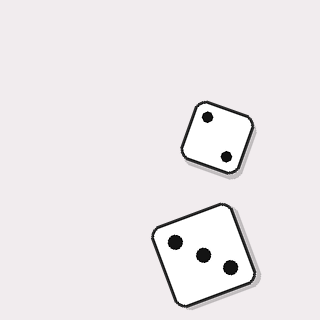

In [68]:
#test
scene = random_scene()
print(scene)
print(describe_scene(scene))

img = render_scene_image(scene)
img

In [62]:
import os
import csv
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class DiceDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split

        self.image_dir = os.path.join(root_dir, split, "images")
        self.csv_path = os.path.join(root_dir, split, "labels.csv")

        self.samples = []

        with open(self.csv_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.samples.append(row)

        if transform is None:
            self.transform = transforms.ToTensor()
        else:
            self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples[idx]

        img_path = os.path.join(self.image_dir, row["image"])
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        values = list(map(int, row["values"].split()))
        num_dice = len(values)

        padded_values = values + [0] * (3 - len(values))

        label = {
            "values": torch.tensor(padded_values, dtype=torch.long),
            "num_dice": torch.tensor(num_dice, dtype=torch.long)
        }

        return image, label

In [63]:
from torch.utils.data import DataLoader

train_dataset = DiceDataset("dataset", split="train")
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

for imgs, labels in train_loader:
    print(imgs.shape)                 # [32, 3, H, W]
    print(labels["values"].shape)     # [32, 3]
    print(labels["num_dice"].shape)   # [32]
    break

torch.Size([32, 3, 320, 320])
torch.Size([32, 3])
torch.Size([32])


In [64]:
import shutil

# --- Dataset generation and split saving ---

def make_clean_dir(path: str):
    """Create a clean directory. Remove it first if it already exists."""
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def split_counts(total: int, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Compute exact counts for train / val / test.
    Ensures the total adds up exactly.
    """
    train_n = int(total * train_ratio)
    val_n = int(total * val_ratio)
    test_n = total - train_n - val_n
    return train_n, val_n, test_n


def generate_dataset(
    output_dir: str = "dataset",
    total_samples: int = 5000,
    seed: int = 42
):
    random.seed(seed)
    np.random.seed(seed)

    # 1. Prepare folders
    make_clean_dir(output_dir)

    split_names = ["train", "val", "test"]
    for split in split_names:
        os.makedirs(os.path.join(output_dir, split, "images"), exist_ok=True)

    # 2. Decide split sizes
    train_n, val_n, test_n = split_counts(total_samples, 0.7, 0.15, 0.15)

    split_plan = (
        ["train"] * train_n +
        ["val"] * val_n +
        ["test"] * test_n
    )

    # Shuffle split assignment so samples are randomly distributed
    random.shuffle(split_plan)

    # 3. Store rows for CSV files
    split_rows = {
        "train": [],
        "val": [],
        "test": []
    }

    # 4. Generate samples
    for i in range(total_samples):
        scene = random_scene()
        text_label = describe_scene(scene)
        image = render_scene_image(scene)

        split = split_plan[i]
        image_filename = f"sample_{i:05d}.png"
        image_path = os.path.join(output_dir, split, "images", image_filename)

        image.save(image_path)

        split_rows[split].append({
            "image": image_filename,
            "text": text_label,
            "num_dice": scene.count(),
            "values": " ".join(str(v) for v in scene.values())
        })

    # 5. Save labels.csv for each split
    for split in split_names:
        csv_path = os.path.join(output_dir, split, "labels.csv")
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f,
                fieldnames=["image", "text", "num_dice", "values"]
            )
            writer.writeheader()
            writer.writerows(split_rows[split])

    # 6. Save split metadata for reproducibility
    meta_path = os.path.join(output_dir, "dataset_info.txt")
    with open(meta_path, "w", encoding="utf-8") as f:
        f.write(f"total_samples: {total_samples}\n")
        f.write(f"seed: {seed}\n")
        f.write(f"train_count: {train_n}\n")
        f.write(f"val_count: {val_n}\n")
        f.write(f"test_count: {test_n}\n")
        f.write("split_ratio: 70/15/15\n")

    print("Dataset generated successfully.")
    print(f"Train: {train_n}, Val: {val_n}, Test: {test_n}")
    print(f"Saved to: {output_dir}")

In [65]:
generate_dataset(output_dir="dataset", total_samples=5000, seed=42)

Dataset generated successfully.
Train: 3500, Val: 750, Test: 750
Saved to: dataset


In [66]:
import os

for split in ["train", "val", "test"]:
    print(f"\n--- {split} ---")
    print(os.listdir(f"dataset/{split}")[:5])  


--- train ---
['images', 'labels.csv']

--- val ---
['images', 'labels.csv']

--- test ---
['images', 'labels.csv']


In [67]:
import os
print(os.getcwd())
print(os.listdir())
print(os.listdir("dataset"))

C:\Users\zhang\Downloads\text_labs_public-main\text_labs_public-main\coursework
['.ipynb_checkpoints', 'dataset', 'dataset.zip', 'ebm_nlp_2_00.tar.gz', 'kaggle_data', 'task1_pubmedqa.ipynb', 'task2_ebm-nlp.ipynb', 'task3_arxiv.ipynb', 'task4_customer_support.ipynb', 'task5_tictactoe.py', 'test_1.mat', 'test_1.meta', 'test_1.png', 'test_1.txt', 'test_2.mat', 'test_2.meta', 'test_2.png', 'test_2.txt', 'test_3.mat', 'test_3.meta', 'test_3.png', 'test_3.txt', 'test_4.mat', 'test_4.meta', 'test_4.png', 'test_4.txt', 'test_5.mat', 'test_5.meta', 'test_5.png', 'test_5.txt', 'Untitled.ipynb', 'Untitled1.ipynb']
['dataset_info.txt', 'test', 'train', 'val']
